In [1]:
# importing packages
import pyomo.environ as pyo
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from scipy.interpolate import griddata
import math
import scipy.stats as stats
from scipy.optimize import fsolve, bisect
import pandas as pd
import conductivity as cd

# Double Salts Prediction

## Data for Double Salts

In [2]:
# loading NaCl and CaCl2 experiment data
data = pd.read_csv("./Data/NaCl_CaCl2_rearranged.csv")
NaCl_conc = data["NaCl conc"]
NaCl_conc12 = data["NaCl conc2"]
NaCl_conc13 = data["NaCl conc3"]
CaCl2_conc = data["CaCl2 conc"]
CaCl2_conc12 = data["CaCl2 conc2"]
CaCl2_conc13 = data["CaCl2 conc3"]
cond_exp = data["Cal bulk cond"]
cond_exp12 = data["Cal bulk cond2"]
cond_exp13 = data["Cal bulk cond3"]

# measurement error
error_na_ca_1_1 = (-0.00007 * (NaCl_conc + CaCl2_conc) + 0.0102) * cond_exp
error_na_ca_1_2 = (-0.00007 * (NaCl_conc12 + CaCl2_conc12) + 0.0102) * cond_exp12
error_na_ca_2_1 = (-0.00007 * (NaCl_conc13 + CaCl2_conc13) + 0.0102) * cond_exp13

# number of data points
ndata = len(cond_exp)

In [3]:
# loading CaCl2 and LaCl3 experiment data
data2 = pd.read_csv("./Data/CaCl2_LaCl3_rearranged.csv")
LaCl3_conc = data2["LaCl3 conc"]
LaCl3_conc12 = data2["LaCl3 conc2"]
LaCl3_conc13 = data2["LaCl3 conc3"]
CaCl2_conc2 = data2["CaCl2 conc"]
CaCl2_conc22 = data2["CaCl2 conc2"]
CaCl2_conc23 = data2["CaCl2 conc3"]
cond_exp2 = data2["Cal bulk cond"]
cond_exp22 = data2["Cal bulk cond2"]
cond_exp23 = data2["Cal bulk cond3"]

# measurement error
error_ca_la_1_1 = (-0.00007 * (LaCl3_conc + CaCl2_conc2) + 0.0102) * cond_exp2
error_ca_la_2_1 = (-0.00007 * (LaCl3_conc12 + CaCl2_conc22) + 0.0102) * cond_exp22
error_ca_la_1_2 = (-0.00007 * (LaCl3_conc13 + CaCl2_conc23) + 0.0102) * cond_exp23

# number of data points
ndata2 = len(cond_exp2)

In [4]:
# loading NaCl and LaCl3 experiment data
data4 = pd.read_csv("./Data/NaCl_LaCl3_rearranged.csv")
NaCl_conc2 = data4["NaCl conc"]
NaCl_conc22 = data4["NaCl conc2"]
NaCl_conc23 = data4["NaCl conc3"]
LaCl3_conc2 = data4["LaCl3 conc"]
LaCl3_conc22 = data4["LaCl3 conc2"]
LaCl3_conc23 = data4["LaCl3 conc3"]
cond_exp3 = data4["Cal bulk cond"]
cond_exp32 = data4["Cal bulk cond2"]
cond_exp33 = data4["Cal bulk cond3"]

# measurement error
error_na_la_1_1 = (-0.00007 * (NaCl_conc2 + LaCl3_conc2) + 0.0102) * cond_exp3
error_na_la_3_1 = (-0.00007 * (NaCl_conc22 + LaCl3_conc22) + 0.0102) * cond_exp32
error_na_la_1_2 = (-0.00007 * (NaCl_conc23 + LaCl3_conc23) + 0.0102) * cond_exp33

# number of data points
ndata4 = len(cond_exp3)

## Constants

In [5]:
# temperature in K
T = 298.15

# diffusion coefficients at infinite dilution in m^2/s
Diff_Na = 1.334 * 10**(-9)
Diff_Cl = 2.032 * 10**(-9)
Diff_Ca = 0.792 * 10**(-9)
Diff_La = 0.619 * 10**(-9)
Diff_Li = 1.029 * 10**(-9)
Diff_H = 9.311 * 10**(-9)
Diff_Co = 0.732 * 10**(-9)

# valencies
z_Na = 1
z_Cl = -1
z_Ca = 2
z_La = 3

# hard sphere diameters in m
sigma_Cl = 2 * 181 * 10**(-12)
sigma_Ca = 2 * 100 * 10**(-12)
sigma_La = 2 * 118 * 10**(-12)
sigma_Na = 2 * 102 * 10**(-12)
sigma_Li = 2 * 74 * 10**(-12)
sigma_H = 2 * 37 * 10**(-12)
sigma_Co = 2 * 75 * 10**(-12)

# solvent viscosity in Pa.s
eta = 0.89 * 10**(-3)

# relative permittivity
epsilon = 78.43

# limiting molar conductivity of ions in m^2.S/mol
lambda_0_Na_mol = 50.08 * 10**(-4)
lambda_0_Cl_mol = 76.31 * 10**(-4)
lambda_0_Ca_mol = 59.47 * 10**(-4)
lambda_0_La_mol = 69.7 * 10**(-4)
lambda_0_Li_mol = 38.66 * 10**(-4)
lambda_0_H_mol = 349.65 * 10**(-4)
lambda_0_Co_mol = 55 * 10**(-4)

# MSA Transport Model

## NaCl and CaCl2

In [6]:
# constants
diffusion_coeff = [Diff_Ca, Diff_Na, Diff_Cl] # diffusion coefficients of Ca, Na, and Cl, respectively
valency = [z_Ca, z_Na, z_Cl] # valencies of Ca, Na, and Cl, respectively
diameter = [sigma_Ca, sigma_Na, sigma_Cl] # effective ionic diameters of Ca, Na, and Cl, respectively
lambda_0_Ca_Na_Cl = [lambda_0_Ca_mol, lambda_0_Na_mol, lambda_0_Cl_mol]

# calculated conductivity in uS/cm
all_cond_calc_con =cd.msa_transport(valency, diameter, diffusion_coeff, T, eta, epsilon, lambda_0_Ca_Na_Cl, CaCl2_conc, NaCl_conc)
all_cond_calc_con12 = cd.msa_transport(valency, diameter, diffusion_coeff, T, eta, epsilon, lambda_0_Ca_Na_Cl, CaCl2_conc12, NaCl_conc12)
all_cond_calc_con13 = cd.msa_transport(valency, diameter, diffusion_coeff, T, eta, epsilon, lambda_0_Ca_Na_Cl, CaCl2_conc13, NaCl_conc13)

Relaxation correction: [-0.11131282 -0.03908867 -0.08723811]
Hydrodynamic correction: [-0.34150633 -0.20230851 -0.12231221]
omega_bar: 321740280365.1725
Alpha: [0.0, 275118320719.31915, 381397438525.5137]
Mew: [0.5   0.125 0.375]
Transport number: [0.29892433 0.12587281 0.57520287]
Omega: [1.92351992e+11 3.23986816e+11 4.93509152e+11]
ksi: [[ 1.52379051 -0.94333929 -0.36537891]
 [ 0.90467922  2.09978239 -1.64833163]
 [ 0.59391835  0.55785826  1.03661575]]
Relaxation correction: [-0.10289564 -0.03539905 -0.08939632]
Hydrodynamic correction: [-0.32515356 -0.19264358 -0.11691451]
omega_bar: 309310608411.8851
Alpha: [0.0, 291839212055.8278, 374919546231.9499]
Mew: [0.57142857 0.07142857 0.35714286]
Transport number: [0.35535614 0.07481772 0.56982614]
Omega: [1.92351992e+11 3.23986816e+11 4.93509152e+11]
ksi: [[ 1.46130484 -0.71446761 -0.41012496]
 [ 0.86758128  2.92813261 -2.00976597]
 [ 0.5695637   0.55752166  1.05815313]]
Relaxation correction: [-0.10505232 -0.0376572  -0.07135476]
Hydro

In [7]:
def ionic_strength(salt_1_conc, salt_2_conc, valency):
    """ Calculates the ionic strength of the salt solution

        Arguments:
            salt_conc_1: list or np.array of the concentration of the higher valency salt in mM
            salt_conc_2: list or np.array of the concentration of the lower valency salt in mM
            valency: list of the valency of ions in decreasing order

        Returns:
            ionic_strength: ionic strength of the salt solution
    """
    # calculate the species concentration
    ndata = len(salt_1_conc)
    cation_1_conc = salt_1_conc
    cation_2_conc = salt_2_conc
    anion_conc = [valency[0] * salt_1_conc[i] + valency[1] * salt_2_conc[i] for i in range(ndata)]
    n_species = len(valency)
    
    # calculate the ionic stength of the solution
    ionic_strength = []
    for i in range(ndata):
        ion_conc = [cation_1_conc[i], cation_2_conc[i], anion_conc[i]]
        ionic_strength.append(0.5 * sum(ion_conc[j] * valency[j] ** 2 for j in range(n_species)))

    return ionic_strength

# calculate the ionic strengths
ionic_strength_na_ca_1_1 = ionic_strength(CaCl2_conc, NaCl_conc, valency)
ionic_strength_na_ca_1_2 = ionic_strength(CaCl2_conc12, NaCl_conc12, valency)
ionic_strength_na_ca_2_1 = ionic_strength(CaCl2_conc13, NaCl_conc13, valency)

In [8]:
# residuals for NaCl and CaCl2
e = [all_cond_calc_con[i] - cond_exp[i] for i in range(ndata)]
e12 = [all_cond_calc_con12[i] - cond_exp12[i] for i in range(ndata)]
e13 = [all_cond_calc_con13[i] - cond_exp13[i] for i in range(ndata)]

# residuals percent or fraction
residuals_percent = [100*e[i]/cond_exp[i] for i in range(ndata)]
residuals_percent12 = [100*e12[i]/cond_exp12[i] for i in range(ndata)]
residuals_percent13 = [100*e13[i]/cond_exp13[i] for i in range(ndata)]

# calculate the mean absolute percent error
residuals_percent_abs = [np.abs(residuals_percent[i]) for i in range(ndata)]
residuals_percent12_abs = [np.abs(residuals_percent12[i]) for i in range(ndata)]
residuals_percent13_abs = [np.abs(residuals_percent13[i]) for i in range(ndata)]
print("The mean absolute percent error of 1:1 is:",np.mean(residuals_percent_abs))
print("The mean absolute percent error of 1:2 is:",np.mean(residuals_percent12_abs))
print("The mean absolute percent error of 2:1 is:",np.mean(residuals_percent13_abs))

# calculate the mean absolute error
residuals_abs = [np.abs(e[i]) for i in range(ndata)]
residuals_12_abs = [np.abs(e12[i]) for i in range(ndata)]
residuals_13_abs = [np.abs(e13[i]) for i in range(ndata)]
print("\nThe mean absolute error of 1:1 is:",np.mean(residuals_abs))
print("The mean absolute error of 1:2 is:",np.mean(residuals_12_abs))
print("The mean absolute error of 2:1 is:",np.mean(residuals_13_abs))

# calculate the mean squared error
sq_residuals = [e[i]**2 for i in range(ndata)]
sq_residuals_12 = [e12[i]**2 for i in range(ndata)]
sq_residuals_13 = [e13[i]**2 for i in range(ndata)]
print("\nThe mean squared error of 1:1 is:",np.mean(sq_residuals))
print("The mean squared error of 1:2 is:",np.mean(sq_residuals_12))
print("The mean squared error of 2:1 is:",np.mean(sq_residuals_13))

The mean absolute percent error of 1:1 is: 2.371217789810701
The mean absolute percent error of 1:2 is: 3.173985103146559
The mean absolute percent error of 2:1 is: 2.272267937457787

The mean absolute error of 1:1 is: 201.28123266388133
The mean absolute error of 1:2 is: 225.4142102415953
The mean absolute error of 2:1 is: 126.37028839982845

The mean squared error of 1:1 is: 54457.99919193649
The mean squared error of 1:2 is: 65477.57363468502
The mean squared error of 2:1 is: 19467.04042477857


## CaCl2 and LaCl3

In [9]:
# constants
diffusion_coeff_2 = [Diff_La, Diff_Ca, Diff_Cl] # diffusion coefficients of La, Ca, and Cl, respectively
valency_2 = [z_La, z_Ca, z_Cl] # valencies of La, Ca, and Cl, respectively
diameter_2 = [sigma_La, sigma_Ca, sigma_Cl] # effective ionic diameters of La, Ca, and Cl, respectively
lambda_0_La_Ca_Cl = [lambda_0_La_mol, lambda_0_Ca_mol, lambda_0_Cl_mol]

# calculated conductivity in uS/cm
all_cond_calc_con2 = cd.msa_transport(valency_2, diameter_2, diffusion_coeff_2, T, eta, epsilon, lambda_0_La_Ca_Cl, LaCl3_conc, CaCl2_conc2)
all_cond_calc_con22 = cd.msa_transport(valency_2, diameter_2, diffusion_coeff_2, T, eta, epsilon, lambda_0_La_Ca_Cl, LaCl3_conc12, CaCl2_conc22)
all_cond_calc_con23 = cd.msa_transport(valency_2, diameter_2, diffusion_coeff_2, T, eta, epsilon, lambda_0_La_Ca_Cl, LaCl3_conc13, CaCl2_conc23)

Relaxation correction: [-0.15070863 -0.06378179 -0.11593789]
Hydrodynamic correction: [-0.41124116 -0.32758533 -0.11769067]
omega_bar: 254998618549.4704
Alpha: [0.0, 177514916972.00076, 357552337024.4243]
Mew: [0.5        0.22222222 0.27777778]
Transport number: [0.2947775  0.16762792 0.53759458]
Omega: [1.50335711e+11 1.92351992e+11 4.93509152e+11]
ksi: [[ 1.49560678 -0.98603166 -0.42812508]
 [ 1.1689149   2.0485397  -0.63459947]
 [ 0.45560069  0.13602522  1.27830472]]
Relaxation correction: [-0.17315487 -0.07731703 -0.11839039]
Hydrodynamic correction: [-0.45750594 -0.36525362 -0.13009999]
omega_bar: 264433392030.6449
Alpha: [0.0, 170446449841.47757, 357402378151.1003]
Mew: [0.375      0.33333333 0.29166667]
Transport number: [0.21319506 0.24247063 0.54433432]
Omega: [1.50335711e+11 1.92351992e+11 4.93509152e+11]
ksi: [[ 1.55828361 -1.44328908 -0.42333097]
 [ 1.21790095  1.49901735 -0.62759471]
 [ 0.47469368  0.14249471  1.26153378]]
Relaxation correction: [-0.13488169 -0.05421643 -0

In [10]:
# calculate the ionic strengths
ionic_strength_ca_la_1_1 = ionic_strength(LaCl3_conc, CaCl2_conc2, valency_2)
ionic_strength_ca_la_2_1 = ionic_strength(LaCl3_conc12, CaCl2_conc22, valency_2)
ionic_strength_ca_la_1_2 = ionic_strength(LaCl3_conc13, CaCl2_conc23, valency_2)

In [11]:
# residuals for CaCl2 and LaCl3
e2 = [all_cond_calc_con2[i] - cond_exp2[i] for i in range(ndata2)]
e22 = [all_cond_calc_con22[i] - cond_exp22[i] for i in range(ndata2)]
e23 = [all_cond_calc_con23[i] - cond_exp23[i] for i in range(ndata2)]

# residuals percent or fraction
residuals_percent2 = [100*e2[i]/cond_exp2[i] for i in range(ndata2)]
residuals_percent22 = [100*e22[i]/cond_exp22[i] for i in range(ndata2)]
residuals_percent23 = [100*e23[i]/cond_exp23[i] for i in range(ndata2)]

# absolute value of relative error
residuals_percent2_abs = [np.abs(residuals_percent2[i]) for i in range(ndata2)]
residuals_percent22_abs = [np.abs(residuals_percent22[i]) for i in range(ndata2)]
residuals_percent23_abs = [np.abs(residuals_percent23[i]) for i in range(ndata2)]
print("The mean absolute percent error of 1:1 is:",np.mean(residuals_percent2_abs))
print("The mean absolute percent error of 2:1 is:",np.mean(residuals_percent22_abs))
print("The mean absolute percent error of 1:2 is:",np.mean(residuals_percent23_abs))

# calculate the mean absolute error
residuals_2_abs = [np.abs(e2[i]) for i in range(ndata2)]
residuals_22_abs = [np.abs(e22[i]) for i in range(ndata2)]
residuals_23_abs = [np.abs(e23[i]) for i in range(ndata2)]
print("\nThe mean absolute error of 1:1 is:",np.mean(residuals_2_abs))
print("The mean absolute error of 2:1 is:",np.mean(residuals_22_abs))
print("The mean absolute error of 1:2 is:",np.mean(residuals_23_abs))

# calculate the mean squared error
sq_residuals_2 = [e2[i]**2 for i in range(ndata2)]
sq_residuals_22 = [e22[i]**2 for i in range(ndata2)]
sq_residuals_23 = [e23[i]**2 for i in range(ndata2)]
print("\nThe mean squared error of 1:1 is:",np.mean(sq_residuals_2))
print("The mean squared error of 2:1 is:",np.mean(sq_residuals_22))
print("The mean squared error of 1:2 is:",np.mean(sq_residuals_23))

The mean absolute percent error of 1:1 is: 1.597025758813975
The mean absolute percent error of 2:1 is: 2.475693116395699
The mean absolute percent error of 1:2 is: 1.978075885310331

The mean absolute error of 1:1 is: 102.31572140872045
The mean absolute error of 2:1 is: 232.5915020440187
The mean absolute error of 1:2 is: 117.39622648251091

The mean squared error of 1:1 is: 18842.900505865062
The mean squared error of 2:1 is: 94402.11169394803
The mean squared error of 1:2 is: 24430.964898974045


## NaCl and LaCl3

In [12]:
# constants
diffusion_coeff_3 = [Diff_La, Diff_Na, Diff_Cl] # diffusion coefficients of La, Na, and Cl, respectively
valency_3 = [z_La, z_Na, z_Cl] # valencies of La, Na, and Cl, respectively
diameter_3 = [sigma_La, sigma_Na, sigma_Cl] # effective ionic diameters of La, Na, and Cl, respectively
lambda_0_La_Na_Cl = [lambda_0_La_mol, lambda_0_Na_mol, lambda_0_Cl_mol]

# calculated conductivity in uS/cm
all_cond_calc_con3 = cd.msa_transport(valency_3, diameter_3, diffusion_coeff_3, T, eta, epsilon, lambda_0_La_Na_Cl, LaCl3_conc2, NaCl_conc2)
all_cond_calc_con32 = cd.msa_transport(valency_3, diameter_3, diffusion_coeff_3, T, eta, epsilon, lambda_0_La_Na_Cl, LaCl3_conc22, NaCl_conc22)
all_cond_calc_con33 = cd.msa_transport(valency_3, diameter_3, diffusion_coeff_3, T, eta, epsilon, lambda_0_La_Na_Cl, LaCl3_conc23, NaCl_conc23)

Relaxation correction: [-0.13744596 -0.01647846 -0.10720408]
Hydrodynamic correction: [-0.37274898 -0.17563275 -0.10724013]
omega_bar: 260788916222.98755
Alpha: [0.0, 280185123994.9613, 378474712351.47736]
Mew: [0.64285714 0.07142857 0.28571429]
Transport number: [0.37058471 0.08873811 0.54067718]
Omega: [1.50335711e+11 3.23986816e+11 4.93509152e+11]
ksi: [[ 1.50778913 -0.58944861 -0.27849707]
 [ 0.69964128  2.68345218 -1.89174574]
 [ 0.45931175  0.65539633  1.09955484]]
Relaxation correction: [-0.17116259 -0.02670757 -0.09893508]
Hydrodynamic correction: [-0.40925151 -0.19314246 -0.1171157 ]
omega_bar: 293668709070.8091
Alpha: [0.0, 242876329097.13528, 388092787538.26306]
Mew: [0.5        0.16666667 0.33333333]
Transport number: [0.25596141 0.18387319 0.5601654 ]
Omega: [1.50335711e+11 3.23986816e+11 4.93509152e+11]
ksi: [[ 1.69629658 -0.98749428 -0.23296339]
 [ 0.78711213  1.6842391  -1.40795025]
 [ 0.51673602  0.63912188  1.0534202 ]]
Relaxation correction: [-0.12637798 -0.01308509 

In [13]:
# calculate the ionic strengths
ionic_strength_na_la_1_1 = ionic_strength(LaCl3_conc2, NaCl_conc2, valency_3)
ionic_strength_na_la_3_1 = ionic_strength(LaCl3_conc22, NaCl_conc22, valency_3)
ionic_strength_na_la_1_2 = ionic_strength(LaCl3_conc23, NaCl_conc23, valency_3)

In [14]:
# residuals for NaCl and LaCl3
e3 = [all_cond_calc_con3[i] - cond_exp3[i] for i in range(ndata4)]
e32 = [all_cond_calc_con32[i] - cond_exp32[i] for i in range(ndata4)]
e33 = [all_cond_calc_con33[i] - cond_exp33[i] for i in range(ndata4)]

# residuals percent or fraction
residuals_percent3 = [100*e3[i]/cond_exp3[i] for i in range(ndata4)]
residuals_percent32 = [100*e32[i]/cond_exp32[i] for i in range(ndata4)]
residuals_percent33 = [100*e33[i]/cond_exp33[i] for i in range(ndata4)]

# absolute value of relative error
residuals_percent3_abs = [np.abs(residuals_percent3[i]) for i in range(ndata4)]
residuals_percent32_abs = [np.abs(residuals_percent32[i]) for i in range(ndata4)]
residuals_percent33_abs = [np.abs(residuals_percent33[i]) for i in range(ndata4)]
print("The mean absolute percent error of 1:1 is:",np.mean(residuals_percent3_abs))
print("The mean absolute percent error of 3:1 is:",np.mean(residuals_percent32_abs))
print("The mean absolute percent error of 1:2 is:",np.mean(residuals_percent33_abs))

# calculate the mean absolute error
residuals_3_abs = [np.abs(e3[i]) for i in range(ndata4)]
residuals_32_abs = [np.abs(e32[i]) for i in range(ndata4)]
residuals_33_abs = [np.abs(e33[i]) for i in range(ndata4)]
print("\nThe mean absolute error of 1:1 is:",np.mean(residuals_3_abs))
print("The mean absolute error of 3:1 is:",np.mean(residuals_32_abs))
print("The mean absolute error of 1:2 is:",np.mean(residuals_33_abs))

# calculate the mean squared error
sq_residuals_3 = [e3[i]**2 for i in range(ndata4)]
sq_residuals_32 = [e32[i]**2 for i in range(ndata4)]
sq_residuals_33 = [e33[i]**2 for i in range(ndata4)]
print("\nThe mean squared error of 1:1 is:",np.mean(sq_residuals_3))
print("The mean squared error of 3:1 is:",np.mean(sq_residuals_32))
print("The mean squared error of 1:2 is:",np.mean(sq_residuals_33))

The mean absolute percent error of 1:1 is: 1.934141894064987
The mean absolute percent error of 3:1 is: 2.024625966598876
The mean absolute percent error of 1:2 is: 1.3278691827614337

The mean absolute error of 1:1 is: 103.94609747529721
The mean absolute error of 3:1 is: 162.64755099484904
The mean absolute error of 1:2 is: 66.29430993585804

The mean squared error of 1:1 is: 17439.479027762376
The mean squared error of 3:1 is: 45209.29863589316
The mean squared error of 1:2 is: 7951.674608745649


# Variant Shedlovsky Model

## NaCl and CaCl2 Model Comparison

### Constants

In [15]:
# solvent viscosity in poise
eta_shed = 8.903*10**(-3)

# limiting equivalent conductivity of salts in cm^2.Siemen.equiv^(-1)
lambda_0_NaCl = 126.45 
lambda_0_CaCl2 = 135.85
lambda_0_LaCl3 = 145.9

# limiting equivalent conductivity of ions in cm^2.Siemen.equiv^(-1)
lambda_0_Na = 50.10 
lambda_0_Ca = 59.5
lambda_0_La = 69.7
lambda_0_Cl = 76.35

# distance from an ion within which no other ion can penetrate in cm
a_NaCl = 4*10**(-8)
a_CaCl2 = 4.31*10**(-8)
a_LaCl3 = 4.9*10**(-8)

### NaCl

In [16]:
# constants
temp_NaCl_CaCl2 = 298.16 # K
epsilon = 78.3
eta = 8.903*10**(-3) # poise
a_NaCl_CaCl2 = (a_NaCl + a_CaCl2)/2

# concentration in M
conc = [NaCl_conc[i]*10**(-3) for i in range(ndata)]
conc12 = [NaCl_conc12[i]*10**(-3) for i in range(ndata)]
conc13 = [NaCl_conc13[i]*10**(-3) for i in range(ndata)]

# specific conductivity in micro Siemen per cm
specific_cond_nacl = cd.variant_shedlovsky(conc, temp_NaCl_CaCl2, epsilon, eta, lambda_0_NaCl, a_NaCl_CaCl2, z_Na, z_Cl, lambda_0_Na, lambda_0_Cl)
specific_cond_nacl_12 = cd.variant_shedlovsky(conc12, temp_NaCl_CaCl2, epsilon, eta, lambda_0_NaCl, a_NaCl_CaCl2, z_Na, z_Cl, lambda_0_Na, lambda_0_Cl)
specific_cond_nacl_13 = cd.variant_shedlovsky(conc13, temp_NaCl_CaCl2, epsilon, eta, lambda_0_NaCl, a_NaCl_CaCl2, z_Na, z_Cl, lambda_0_Na, lambda_0_Cl)

### CaCl2

In [17]:
# concentration in M
conc_cacl2 = [CaCl2_conc[i]*10**(-3) for i in range(ndata)]
conc_cacl2_12 = [CaCl2_conc12[i]*10**(-3) for i in range(ndata)]
conc_cacl2_13 = [CaCl2_conc13[i]*10**(-3) for i in range(ndata)]

# specific conductivity in micro Siemen per cm
specific_cond_cacl2 = cd.variant_shedlovsky(conc_cacl2, temp_NaCl_CaCl2, epsilon, eta, lambda_0_CaCl2, a_NaCl_CaCl2, z_Ca, z_Cl, lambda_0_Ca, 
                                             lambda_0_Cl)
specific_cond_cacl2_12 = cd.variant_shedlovsky(conc_cacl2_12, temp_NaCl_CaCl2, epsilon, eta, lambda_0_CaCl2, a_NaCl_CaCl2, z_Ca, z_Cl, lambda_0_Ca, 
                                                lambda_0_Cl)
specific_cond_cacl2_13 = cd.variant_shedlovsky(conc_cacl2_13, temp_NaCl_CaCl2, epsilon, eta, lambda_0_CaCl2, a_NaCl_CaCl2, z_Ca, z_Cl, lambda_0_Ca, 
                                                lambda_0_Cl)

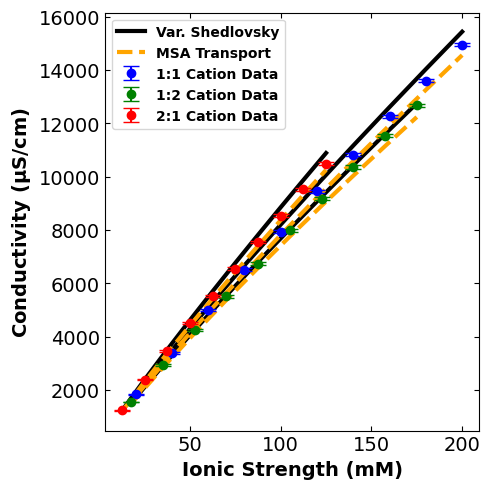

In [18]:
# bulk conductivity
specific_cond = [specific_cond_nacl[i] + specific_cond_cacl2[i] for i in range(ndata)]
specific_cond_12 = [specific_cond_nacl_12[i] + specific_cond_cacl2_12[i] for i in range(ndata)]
specific_cond_13 = [specific_cond_nacl_13[i] + specific_cond_cacl2_13[i] for i in range(ndata)]

# making plot comparison of calculated and experimental conductivity of NaCl and CaCl2
fig = plt.figure(figsize=(5, 5))
plt.plot(ionic_strength_na_ca_1_1, specific_cond, "-", color="black", linewidth=3, label="Var. Shedlovsky")
plt.plot(ionic_strength_na_ca_1_2, specific_cond_12, "-", linewidth=3, color="black")
plt.plot(ionic_strength_na_ca_2_1, specific_cond_13, "-", color="black", linewidth=3)
plt.plot(ionic_strength_na_ca_1_1, all_cond_calc_con, "--", color="orange", linewidth=3, label="MSA Transport")
plt.plot(ionic_strength_na_ca_1_2, all_cond_calc_con12, "--", color="orange", linewidth=3)
plt.plot(ionic_strength_na_ca_2_1, all_cond_calc_con13, "--", color="orange", linewidth=3)
plt.errorbar(
    ionic_strength_na_ca_1_1, cond_exp, yerr=error_na_ca_1_1, fmt='o', ecolor='blue', capsize=6, markersize=6, markerfacecolor='blue',
    markeredgecolor='blue', label='1:1 Cation Data')
plt.errorbar(
    ionic_strength_na_ca_1_2, cond_exp12, yerr=error_na_ca_1_2, fmt='o', ecolor='green', capsize=6, markersize=6, markerfacecolor='green',
    markeredgecolor='green', label='1:2 Cation Data')
plt.errorbar(
    ionic_strength_na_ca_2_1, cond_exp13, yerr=error_na_ca_2_1, fmt='o', ecolor='red', capsize=6, markersize=6, markerfacecolor='red',
    markeredgecolor='red', label='2:1 Cation Data')
plt.xlabel("Ionic Strength (mM)", fontsize=14,fontweight='bold')
plt.ylabel("Conductivity ($\mathbf{\mu}$S/cm)", fontsize=14,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(r".\Paper_figures\msa_var_shed_na_ca.png")
plt.show()

In [19]:
# residuals for NaCl and CaCl2
e_2 = [specific_cond[i] - cond_exp[i] for i in range(ndata)]
e12_2 = [specific_cond_12[i] - cond_exp12[i] for i in range(ndata)]
e13_2 = [specific_cond_13[i] - cond_exp13[i] for i in range(ndata)]

The mean absolute percent error of 1:1 is: 2.7865910248423167
The mean absolute percent error of 1:2 is: 0.8887307854883193
The mean absolute percent error of 2:1 is: 2.6357674864908147

The mean absolute error of 1:1 is: 252.23016294143258
The mean absolute error of 1:2 is: 51.238155361773764
The mean absolute error of 2:1 is: 190.1536245577899

The mean squared error of 1:1 is: 84157.36056821275
The mean squared error of 1:2 is: 3112.763305521814
The mean squared error of 2:1 is: 54023.08729388493


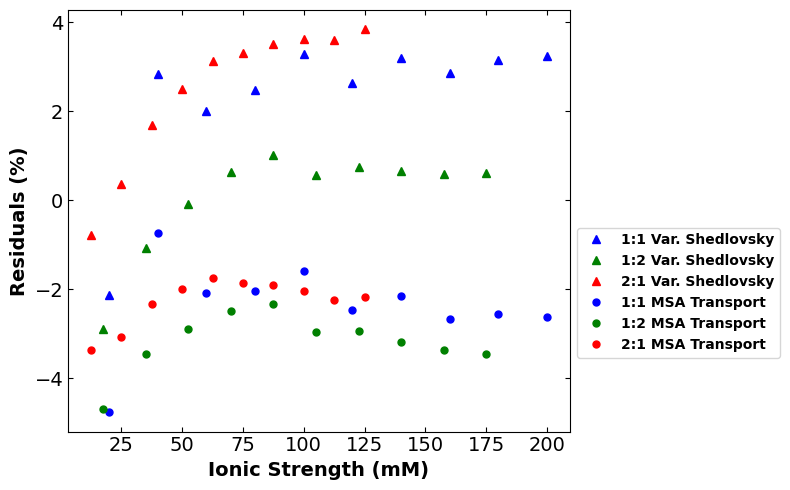

In [20]:
# residuals fraction
residuals_percent_2 = [100*e_2[i]/cond_exp[i] for i in range(ndata)]
residuals_percent12_2 = [100*e12_2[i]/cond_exp12[i] for i in range(ndata)]
residuals_percent13_2 = [100*e13_2[i]/cond_exp13[i] for i in range(ndata)]

# calculate the mean absolute percent error
residuals_percent_2_abs = [np.abs(residuals_percent_2[i]) for i in range(ndata)]
residuals_percent12_2_abs = [np.abs(residuals_percent12_2[i]) for i in range(ndata)]
residuals_percent13_2_abs = [np.abs(residuals_percent13_2[i]) for i in range(ndata)]
print("The mean absolute percent error of 1:1 is:",np.mean(residuals_percent_2_abs))
print("The mean absolute percent error of 1:2 is:",np.mean(residuals_percent12_2_abs))
print("The mean absolute percent error of 2:1 is:",np.mean(residuals_percent13_2_abs))

# calculate the mean absolute error
residuals_abs_shed = [np.abs(e_2[i]) for i in range(ndata)]
residuals_12_abs_shed = [np.abs(e12_2[i]) for i in range(ndata)]
residuals_13_abs_shed = [np.abs(e13_2[i]) for i in range(ndata)]
print("\nThe mean absolute error of 1:1 is:",np.mean(residuals_abs_shed))
print("The mean absolute error of 1:2 is:",np.mean(residuals_12_abs_shed))
print("The mean absolute error of 2:1 is:",np.mean(residuals_13_abs_shed))

# calculate the mean squared error
sq_residuals_shed = [e_2[i]**2 for i in range(ndata)]
sq_residuals_12_shed = [e12_2[i]**2 for i in range(ndata)]
sq_residuals_13_shed = [e13_2[i]**2 for i in range(ndata)]
print("\nThe mean squared error of 1:1 is:",np.mean(sq_residuals_shed))
print("The mean squared error of 1:2 is:",np.mean(sq_residuals_12_shed))
print("The mean squared error of 2:1 is:",np.mean(sq_residuals_13_shed))

# making plots of residuals
fig = plt.figure(figsize=(8, 5))
plt.plot(ionic_strength_na_ca_1_1, residuals_percent_2, "^", color="blue", label="1:1 Var. Shedlovsky")
plt.plot(ionic_strength_na_ca_1_2, residuals_percent12_2, "^", color="green", label="1:2 Var. Shedlovsky")
plt.plot(ionic_strength_na_ca_2_1, residuals_percent13_2, "^", color="red", label="2:1 Var. Shedlovsky")
plt.plot(ionic_strength_na_ca_1_1, residuals_percent, ".", markersize=10, color="blue", label="1:1 MSA Transport")
plt.plot(ionic_strength_na_ca_1_2, residuals_percent12, ".", markersize=10, color="green", label="1:2 MSA Transport")
plt.plot(ionic_strength_na_ca_2_1, residuals_percent13, ".", markersize=10, color="red", label="2:1 MSA Transport")
plt.xlabel("Ionic Strength (mM)", fontsize=14,fontweight='bold')
plt.ylabel("Residuals (%)", fontsize=14,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight":"bold"}, bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.savefig(r".\Paper_figures\msa_var_shed_na_ca_residuals_per.png")
plt.show()

## NaCl and LaCl3 Model Comparison

### NaCl

In [21]:
# constants
temp_NaCl_LaCl3 = 298.16 # K
epsilon = 78.3
eta = 8.903*10**(-3) # poise
a_NaCl_LaCl3 = (a_NaCl + a_LaCl3)/2

# concentration in M
conc_nacl_21 = [NaCl_conc2[i]*10**(-3) for i in range(ndata4)]
conc_nacl_22 = [NaCl_conc22[i]*10**(-3) for i in range(ndata4)]
conc_nacl_23 = [NaCl_conc23[i]*10**(-3) for i in range(ndata4)]

# specific conductivity in micro Siemen per cm
specific_cond_nacl_21 = cd.variant_shedlovsky(conc_nacl_21, temp_NaCl_LaCl3, epsilon, eta, lambda_0_NaCl, a_NaCl_LaCl3, z_Na, z_Cl, lambda_0_Na, 
                                            lambda_0_Cl)
specific_cond_nacl_22 = cd.variant_shedlovsky(conc_nacl_22, temp_NaCl_LaCl3, epsilon, eta, lambda_0_NaCl, a_NaCl_LaCl3, z_Na, z_Cl, lambda_0_Na, 
                                            lambda_0_Cl)
specific_cond_nacl_23 = cd.variant_shedlovsky(conc_nacl_23, temp_NaCl_LaCl3, epsilon, eta, lambda_0_NaCl, a_NaCl_LaCl3, z_Na, z_Cl, lambda_0_Na, 
                                            lambda_0_Cl)

### LaCl3

In [22]:
# concentration in M
conc_lacl3_11 = [LaCl3_conc2[i]*10**(-3) for i in range(ndata4)]
conc_lacl3_12 = [LaCl3_conc22[i]*10**(-3) for i in range(ndata4)]
conc_lacl3_13 = [LaCl3_conc23[i]*10**(-3) for i in range(ndata4)]

# specific conductivity in micro Siemen per cm
specific_cond_lacl3_11 = cd.variant_shedlovsky(conc_lacl3_11, temp_NaCl_LaCl3, epsilon, eta, lambda_0_LaCl3, a_NaCl_LaCl3, z_La, z_Cl, lambda_0_La, 
                                             lambda_0_Cl)
specific_cond_lacl3_12 = cd.variant_shedlovsky(conc_lacl3_12, temp_NaCl_LaCl3, epsilon, eta, lambda_0_LaCl3, a_NaCl_LaCl3, z_La, z_Cl, lambda_0_La, 
                                             lambda_0_Cl)
specific_cond_lacl3_13 = cd.variant_shedlovsky(conc_lacl3_13, temp_NaCl_LaCl3, epsilon, eta, lambda_0_LaCl3, a_NaCl_LaCl3, z_La, z_Cl, lambda_0_La, 
                                             lambda_0_Cl)

### NaCl & LaCl3

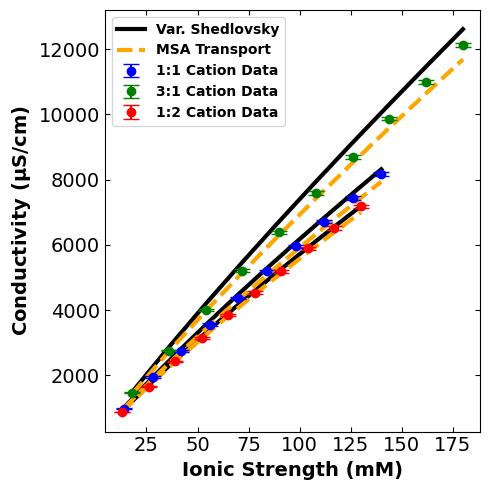

In [23]:
# bulk conductivity
specific_cond_21 = [specific_cond_nacl_21[i] + specific_cond_lacl3_11[i] for i in range(ndata4)]
specific_cond_22 = [specific_cond_nacl_22[i] + specific_cond_lacl3_12[i] for i in range(ndata4)]
specific_cond_23 = [specific_cond_nacl_23[i] + specific_cond_lacl3_13[i] for i in range(ndata4)]

# making plot comparison of calculated and experimental conductivity of NaCl and CaCl2
fig = plt.figure(figsize=(5, 5))
plt.plot(ionic_strength_na_la_1_1, specific_cond_21, "-", color="black", linewidth=3, label="Var. Shedlovsky")
plt.plot(ionic_strength_na_la_3_1, specific_cond_22, "-", linewidth=3, color="black")
plt.plot(ionic_strength_na_la_1_2, specific_cond_23, "-", color="black", linewidth=3)
plt.plot(ionic_strength_na_la_1_1, all_cond_calc_con3, "--", color="orange", linewidth=3, label="MSA Transport")
plt.plot(ionic_strength_na_la_3_1, all_cond_calc_con32, "--", color="orange", linewidth=3)
plt.plot(ionic_strength_na_la_1_2, all_cond_calc_con33, "--", color="orange", linewidth=3)
plt.errorbar(
    ionic_strength_na_la_1_1, cond_exp3, yerr=error_na_la_1_1, fmt='o', ecolor='blue', capsize=6, markersize=6, markerfacecolor='blue',
    markeredgecolor='blue', label='1:1 Cation Data')
plt.errorbar(
    ionic_strength_na_la_3_1, cond_exp32, yerr=error_na_la_3_1, fmt='o', ecolor='green', capsize=6, markersize=6, markerfacecolor='green',
    markeredgecolor='green', label='3:1 Cation Data')
plt.errorbar(
    ionic_strength_na_la_1_2, cond_exp33, yerr=error_na_la_1_2, fmt='o', ecolor='red', capsize=6, markersize=6, markerfacecolor='red',
    markeredgecolor='red', label='1:2 Cation Data')
plt.xlabel("Ionic Strength (mM)", fontsize=14,fontweight='bold')
plt.ylabel("Conductivity ($\mathbf{\mu}$S/cm)", fontsize=14,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(r".\Paper_figures\msa_var_shed_na_la.png")
plt.show()

In [24]:
# residuals for NaCl and LaCl3
e3_2 = [specific_cond_21[i] - cond_exp3[i] for i in range(ndata4)]
e32_2 = [specific_cond_22[i] - cond_exp32[i] for i in range(ndata4)]
e33_2 = [specific_cond_23[i] - cond_exp33[i] for i in range(ndata4)]

The mean absolute percent error of 1:1 is: 2.125384853139745
The mean absolute percent error of 3:1 is: 4.2613093160673525
The mean absolute percent error of 1:2 is: 1.2663909195761114

The mean absolute error of 1:1 is: 94.1937235292113
The mean absolute error of 3:1 is: 311.87013925396593
The mean absolute error of 1:2 is: 37.889963397003456

The mean squared error of 1:1 is: 10459.127315318756
The mean squared error of 3:1 is: 121809.36196565659
The mean squared error of 1:2 is: 1747.6368614453108


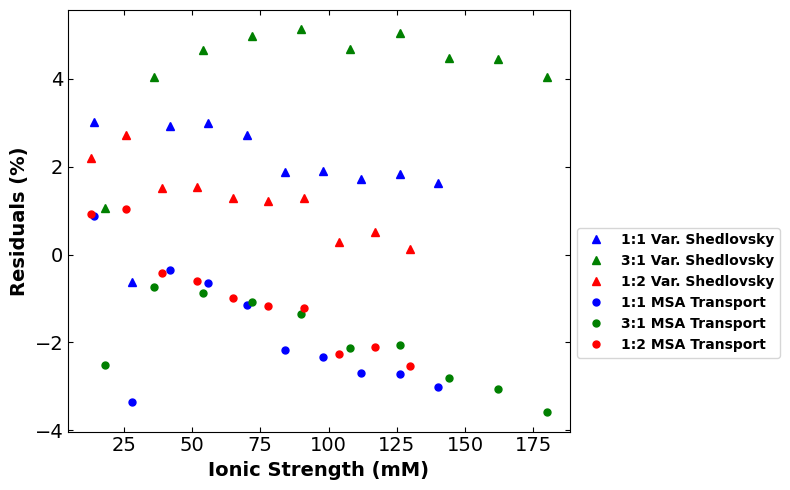

In [25]:
# residuals fraction
residuals_percent3_2 = [100*e3_2[i]/cond_exp3[i] for i in range(ndata4)]
residuals_percent32_2 = [100*e32_2[i]/cond_exp32[i] for i in range(ndata4)]
residuals_percent33_2 = [100*e33_2[i]/cond_exp33[i] for i in range(ndata4)]

# absolute value of relative error
residuals_percent3_2_abs = [np.abs(residuals_percent3_2[i]) for i in range(ndata4)]
residuals_percent32_2_abs = [np.abs(residuals_percent32_2[i]) for i in range(ndata4)]
residuals_percent33_2_abs = [np.abs(residuals_percent33_2[i]) for i in range(ndata4)]
print("The mean absolute percent error of 1:1 is:",np.mean(residuals_percent3_2_abs))
print("The mean absolute percent error of 3:1 is:",np.mean(residuals_percent32_2_abs))
print("The mean absolute percent error of 1:2 is:",np.mean(residuals_percent33_2_abs))

# calculate the mean absolute error
residuals_3_abs_shed = [np.abs(e3_2[i]) for i in range(ndata4)]
residuals_32_abs_shed = [np.abs(e32_2[i]) for i in range(ndata4)]
residuals_33_abs_shed = [np.abs(e33_2[i]) for i in range(ndata4)]
print("\nThe mean absolute error of 1:1 is:",np.mean(residuals_3_abs_shed))
print("The mean absolute error of 3:1 is:",np.mean(residuals_32_abs_shed))
print("The mean absolute error of 1:2 is:",np.mean(residuals_33_abs_shed))

# calculate the mean squared error
sq_residuals_3_shed = [e3_2[i]**2 for i in range(ndata4)]
sq_residuals_32_shed = [e32_2[i]**2 for i in range(ndata4)]
sq_residuals_33_shed = [e33_2[i]**2 for i in range(ndata4)]
print("\nThe mean squared error of 1:1 is:",np.mean(sq_residuals_3_shed))
print("The mean squared error of 3:1 is:",np.mean(sq_residuals_32_shed))
print("The mean squared error of 1:2 is:",np.mean(sq_residuals_33_shed))

# making plots of residuals
fig = plt.figure(figsize=(8, 5))
plt.plot(ionic_strength_na_la_1_1, residuals_percent3_2, "^", color="blue", label="1:1 Var. Shedlovsky")
plt.plot(ionic_strength_na_la_3_1, residuals_percent32_2, "^", color="green", label="3:1 Var. Shedlovsky")
plt.plot(ionic_strength_na_la_1_2, residuals_percent33_2, "^", color="red", label="1:2 Var. Shedlovsky")
plt.plot(ionic_strength_na_la_1_1, residuals_percent3, ".", markersize=10, color="blue", label="1:1 MSA Transport")
plt.plot(ionic_strength_na_la_3_1, residuals_percent32, ".", markersize=10, color="green", label="3:1 MSA Transport")
plt.plot(ionic_strength_na_la_1_2, residuals_percent33, ".", markersize=10, color="red", label="1:2 MSA Transport")
plt.xlabel("Ionic Strength (mM)", fontsize=14,fontweight='bold')
plt.ylabel("Residuals (%)", fontsize=14,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight":"bold"}, bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.savefig(r".\Paper_figures\msa_var_shed_na_la_residuals_per.png")
plt.show()

## CaCl2 and LaCl3 Model Comparison

### CaCl2

In [26]:
# constants
temp_CaCl2_LaCl3 = 298.16 # K
epsilon = 78.3
eta = 8.903*10**(-3) # poise
a_CaCl2_LaCl3 = (a_CaCl2 + a_LaCl3)/2

# concentration in M
conc_cacl2_21 = [CaCl2_conc2[i]*10**(-3) for i in range(ndata2)]
conc_cacl2_22 = [CaCl2_conc22[i]*10**(-3) for i in range(ndata2)]
conc_cacl2_23 = [CaCl2_conc23[i]*10**(-3) for i in range(ndata2)]

# specific conductivity in micro Siemen per cm
specific_cond_cacl2_21 = cd.variant_shedlovsky(conc_cacl2_21, temp_CaCl2_LaCl3, epsilon, eta, lambda_0_CaCl2, a_CaCl2_LaCl3, z_Ca, z_Cl, lambda_0_Ca, 
                                            lambda_0_Cl)
specific_cond_cacl2_22 = cd.variant_shedlovsky(conc_cacl2_22, temp_CaCl2_LaCl3, epsilon, eta, lambda_0_CaCl2, a_CaCl2_LaCl3, z_Ca, z_Cl, lambda_0_Ca, 
                                            lambda_0_Cl)
specific_cond_cacl2_23 = cd.variant_shedlovsky(conc_cacl2_23, temp_CaCl2_LaCl3, epsilon, eta, lambda_0_CaCl2, a_CaCl2_LaCl3, z_Ca, z_Cl, lambda_0_Ca, 
                                            lambda_0_Cl)

### LaCl3

In [27]:
# concentration in M
conc_lacl3_21 = [LaCl3_conc[i]*10**(-3) for i in range(ndata2)]
conc_lacl3_22 = [LaCl3_conc12[i]*10**(-3) for i in range(ndata2)]
conc_lacl3_23 = [LaCl3_conc13[i]*10**(-3) for i in range(ndata2)]

# specific conductivity in micro Siemen per cm
specific_cond_lacl3_21 = cd.variant_shedlovsky(conc_lacl3_21, temp_CaCl2_LaCl3, epsilon, eta, lambda_0_LaCl3, a_CaCl2_LaCl3, z_La, z_Cl, lambda_0_La, 
                                            lambda_0_Cl)
specific_cond_lacl3_22 = cd.variant_shedlovsky(conc_lacl3_22, temp_CaCl2_LaCl3, epsilon, eta, lambda_0_LaCl3, a_CaCl2_LaCl3, z_La, z_Cl, lambda_0_La, 
                                            lambda_0_Cl)
specific_cond_lacl3_23 = cd.variant_shedlovsky(conc_lacl3_23, temp_CaCl2_LaCl3, epsilon, eta, lambda_0_LaCl3, a_CaCl2_LaCl3, z_La, z_Cl, lambda_0_La, 
                                            lambda_0_Cl)

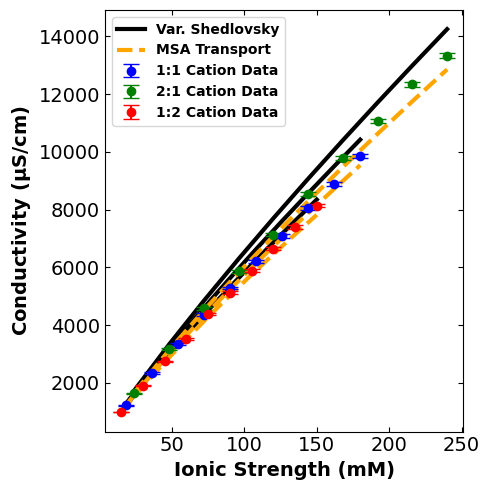

In [28]:
# bulk conductivity
specific_cond_31 = [specific_cond_cacl2_21[i] + specific_cond_lacl3_21[i] for i in range(ndata2)]
specific_cond_32 = [specific_cond_cacl2_22[i] + specific_cond_lacl3_22[i] for i in range(ndata2)]
specific_cond_33 = [specific_cond_cacl2_23[i] + specific_cond_lacl3_23[i] for i in range(ndata2)]

# making plot comparison of calculated and experimental conductivity of NaCl and CaCl2
fig = plt.figure(figsize=(5, 5))
plt.plot(ionic_strength_ca_la_1_1, specific_cond_31, "-", color="black", linewidth=3, label="Var. Shedlovsky")
plt.plot(ionic_strength_ca_la_2_1, specific_cond_32, "-", linewidth=3, color="black")
plt.plot(ionic_strength_ca_la_1_2, specific_cond_33, "-", color="black", linewidth=3)
plt.plot(ionic_strength_ca_la_1_1, all_cond_calc_con2, "--", color="orange", linewidth=3, label="MSA Transport")
plt.plot(ionic_strength_ca_la_2_1, all_cond_calc_con22, "--", color="orange", linewidth=3)
plt.plot(ionic_strength_ca_la_1_2, all_cond_calc_con23, "--", color="orange", linewidth=3)
plt.errorbar(
    ionic_strength_ca_la_1_1, cond_exp2, yerr=error_ca_la_1_1, fmt='o', ecolor='blue', capsize=6, markersize=6, markerfacecolor='blue',
    markeredgecolor='blue', label='1:1 Cation Data')
plt.errorbar(
    ionic_strength_ca_la_2_1, cond_exp22, yerr=error_ca_la_2_1, fmt='o', ecolor='green', capsize=6, markersize=6, markerfacecolor='green',
    markeredgecolor='green', label='2:1 Cation Data')
plt.errorbar(
    ionic_strength_ca_la_1_2, cond_exp23, yerr=error_ca_la_1_2, fmt='o', ecolor='red', capsize=6, markersize=6, markerfacecolor='red',
    markeredgecolor='red', label='1:2 Cation Data')
# plt.plot(ionic_strength_ca_la_1_1, cond_exp2, ".", color="blue", markersize=10, label="1:1 Cation Data")
# plt.plot(ionic_strength_ca_la_2_1, cond_exp22, ".", color="green", markersize=10, label="2:1 Cation Data")
# plt.plot(ionic_strength_ca_la_1_2, cond_exp23, ".", color="red", markersize=10, label="1:2 Cation Data")
plt.xlabel("Ionic Strength (mM)", fontsize=14,fontweight='bold')
plt.ylabel("Conductivity ($\mathbf{\mu}$S/cm)", fontsize=14,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight":"bold"})
plt.tight_layout()
plt.savefig(r".\Paper_figures\msa_var_shed_ca_la.png")
plt.show()

In [29]:
# residuals for CaCl2 and LaCl3
e2_2 = [specific_cond_31[i] - cond_exp2[i] for i in range(ndata2)]
e22_2 = [specific_cond_32[i] - cond_exp22[i] for i in range(ndata2)]
e23_2 = [specific_cond_33[i] - cond_exp23[i] for i in range(ndata2)]

The mean absolute percent error of 1:1 is: 5.56479669302488
The mean absolute percent error of 2:1 is: 6.213878603615317
The mean absolute percent error of 1:2 is: 3.208647694457556

The mean absolute error of 1:1 is: 345.48282414057553
The mean absolute error of 2:1 is: 485.02649987281075
The mean absolute error of 1:2 is: 149.16311272052943

The mean squared error of 1:1 is: 158188.76288963284
The mean squared error of 2:1 is: 292728.0862672686
The mean squared error of 1:2 is: 26805.31292668286


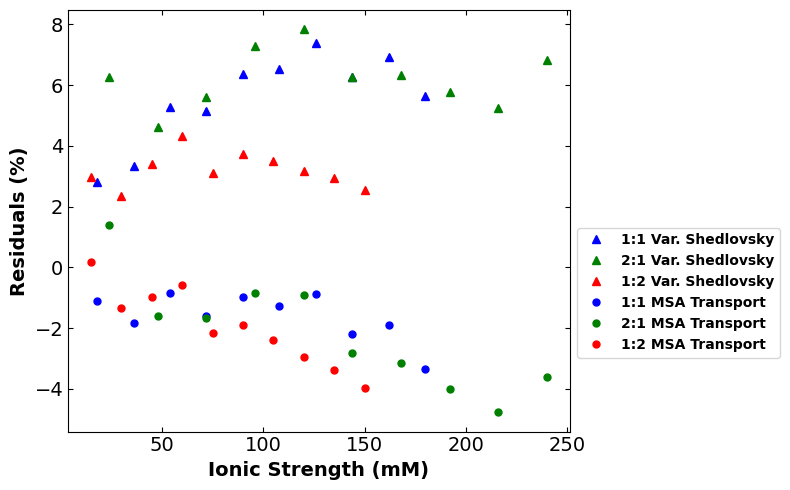

In [30]:
# residuals fraction
residuals_percent2_2 = [100*e2_2[i]/cond_exp2[i] for i in range(ndata2)]
residuals_percent22_2 = [100*e22_2[i]/cond_exp22[i] for i in range(ndata2)]
residuals_percent23_2 = [100*e23_2[i]/cond_exp23[i] for i in range(ndata2)]

# absolute value of relative error
residuals_percent2_2_abs = [np.abs(residuals_percent2_2[i]) for i in range(ndata2)]
residuals_percent22_2_abs = [np.abs(residuals_percent22_2[i]) for i in range(ndata2)]
residuals_percent23_2_abs = [np.abs(residuals_percent23_2[i]) for i in range(ndata2)]
print("The mean absolute percent error of 1:1 is:",np.mean(residuals_percent2_2_abs))
print("The mean absolute percent error of 2:1 is:",np.mean(residuals_percent22_2_abs))
print("The mean absolute percent error of 1:2 is:",np.mean(residuals_percent23_2_abs))

# calculate the mean absolute error
residuals_2_abs_shed = [np.abs(e2_2[i]) for i in range(ndata2)]
residuals_22_abs_shed = [np.abs(e22_2[i]) for i in range(ndata2)]
residuals_23_abs_shed = [np.abs(e23_2[i]) for i in range(ndata2)]
print("\nThe mean absolute error of 1:1 is:",np.mean(residuals_2_abs_shed))
print("The mean absolute error of 2:1 is:",np.mean(residuals_22_abs_shed))
print("The mean absolute error of 1:2 is:",np.mean(residuals_23_abs_shed))

# calculate the mean squared error
sq_residuals_2_shed = [e2_2[i]**2 for i in range(ndata2)]
sq_residuals_22_shed = [e22_2[i]**2 for i in range(ndata2)]
sq_residuals_23_shed = [e23_2[i]**2 for i in range(ndata2)]
print("\nThe mean squared error of 1:1 is:",np.mean(sq_residuals_2_shed))
print("The mean squared error of 2:1 is:",np.mean(sq_residuals_22_shed))
print("The mean squared error of 1:2 is:",np.mean(sq_residuals_23_shed))

# making plots of residuals
fig = plt.figure(figsize=(8, 5))
plt.plot(ionic_strength_ca_la_1_1, residuals_percent2_2, "^", color="blue", label="1:1 Var. Shedlovsky")
plt.plot(ionic_strength_ca_la_2_1, residuals_percent22_2, "^", color="green", label="2:1 Var. Shedlovsky")
plt.plot(ionic_strength_ca_la_1_2, residuals_percent23_2, "^", color="red", label="1:2 Var. Shedlovsky")
plt.plot(ionic_strength_ca_la_1_1, residuals_percent2, ".", markersize=10, color="blue", label="1:1 MSA Transport")
plt.plot(ionic_strength_ca_la_2_1, residuals_percent22, ".", markersize=10, color="green", label="2:1 MSA Transport")
plt.plot(ionic_strength_ca_la_1_2, residuals_percent23, ".", markersize=10, color="red", label="1:2 MSA Transport")
plt.xlabel("Ionic Strength (mM)", fontsize=14,fontweight='bold')
plt.ylabel("Residuals (%)", fontsize=14,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight":"bold"}, bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.savefig(r".\Paper_figures\msa_var_shed_ca_la_residuals_per.png")
plt.show()